# Loss, Optimization, and Training — End-to-End with Iris

This lab opens the `loss_fn` and `optimizer` black boxes, then uses them to train a multi-class model properly.

```text
   MODEL              LOSS               OPTIMIZER
   what CAN be        what "good"        how we MOVE
   represented        means              toward good
```

**Dataset:** Iris — 150 flowers, 4 measurements, 3 species. Small enough to run instantly, real enough to contain every trap you will meet on bigger data.

---
## 1. Setup

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("torch:", torch.__version__, "| device:", device)

torch: 2.12.0 | device: mps


---
## 2. Regression losses: MSE vs MAE vs Huber

$$\text{MSE}=\tfrac1N\sum(\hat y-y)^2 \qquad \text{MAE}=\tfrac1N\sum|\hat y-y| \qquad \text{Huber}=\begin{cases}\tfrac12e^2 & |e|\le\delta\\ \delta(|e|-\tfrac\delta2)&|e|>\delta\end{cases}$$

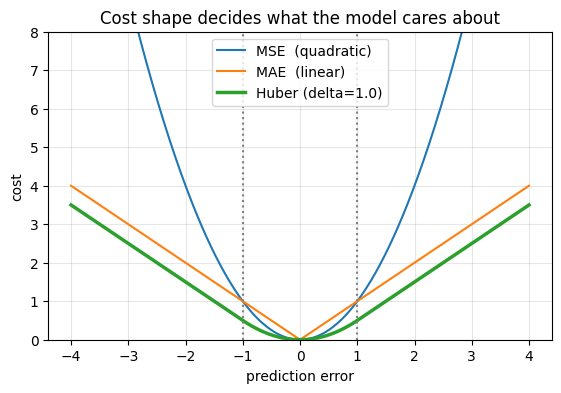

In [2]:
err = torch.linspace(-4, 4, 400)

mse   = err ** 2
mae   = err.abs()
delta = 1.0
huber = torch.where(err.abs() <= delta, 0.5 * err**2, delta * (err.abs() - 0.5 * delta))

plt.figure(figsize=(6.5, 4))
plt.plot(err, mse,   label="MSE  (quadratic)")
plt.plot(err, mae,   label="MAE  (linear)")
plt.plot(err, huber, label=f"Huber (delta={delta})", lw=2.5)
plt.axvline(-delta, ls=":", c="gray"); plt.axvline(delta, ls=":", c="gray")
plt.xlabel("prediction error"); plt.ylabel("cost"); plt.ylim(0, 8)
plt.title("Cost shape decides what the model cares about")
plt.legend(); plt.grid(alpha=.3); plt.show()

In [3]:
# Outlier sensitivity, demonstrated
clean = torch.tensor([2.0, 2.1, 1.9, 2.0, 2.05])
dirty = torch.cat([clean, torch.tensor([50.0])])       # one data-entry error

for name, data in [("clean", clean), ("with 1 outlier", dirty)]:
    c = torch.tensor([2.0], requires_grad=True)
    mse_best = data.mean()
    mae_best = data.median()
    print(f"{name:<16} MSE optimum (mean) = {mse_best:6.2f}   MAE optimum (median) = {mae_best:6.2f}")

print("\nOne bad row drags the MSE optimum from 2.0 to 10.0. The median barely moves.")

clean            MSE optimum (mean) =   2.01   MAE optimum (median) =   2.00
with 1 outlier   MSE optimum (mean) =  10.01   MAE optimum (median) =   2.00

One bad row drags the MSE optimum from 2.0 to 10.0. The median barely moves.


---
## 3. 🔑 Why we cannot train on accuracy

A loss must be **differentiable** — producing gradients is its entire job. Accuracy is piecewise constant, so its derivative is zero almost everywhere.

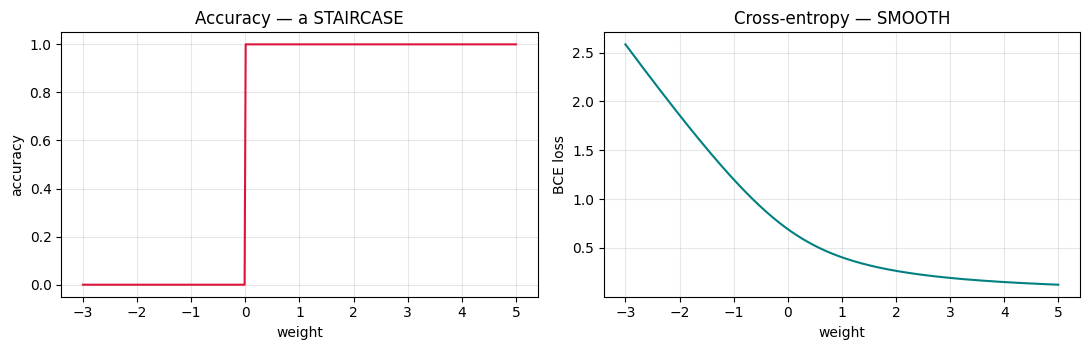

Left : flat almost everywhere -> gradient 0 -> gradient descent goes nowhere.
Right: always has a downhill direction -> trainable.


In [4]:
# Sweep one weight and watch accuracy vs cross-entropy
torch.manual_seed(SEED)
X = torch.randn(200, 1)
y = (X[:, 0] > 0).float().unsqueeze(1)

ws  = torch.linspace(-3, 5, 400)
acc, ce = [], []
for w in ws:
    logits = X * w
    acc.append((((logits.sigmoid() >= .5).float() == y).float().mean()).item())
    ce.append(nn.BCEWithLogitsLoss()(logits, y).item())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(ws, acc, color="crimson"); ax[0].set_title("Accuracy — a STAIRCASE")
ax[0].set_xlabel("weight"); ax[0].set_ylabel("accuracy"); ax[0].grid(alpha=.3)
ax[1].plot(ws, ce, color="teal");    ax[1].set_title("Cross-entropy — SMOOTH")
ax[1].set_xlabel("weight"); ax[1].set_ylabel("BCE loss"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print("Left : flat almost everywhere -> gradient 0 -> gradient descent goes nowhere.")
print("Right: always has a downhill direction -> trainable.")

### Binary cross-entropy, read as two halves

$$L = -\big[\,y\log p + (1-y)\log(1-p)\,\big]$$

Exactly one term is alive per example.

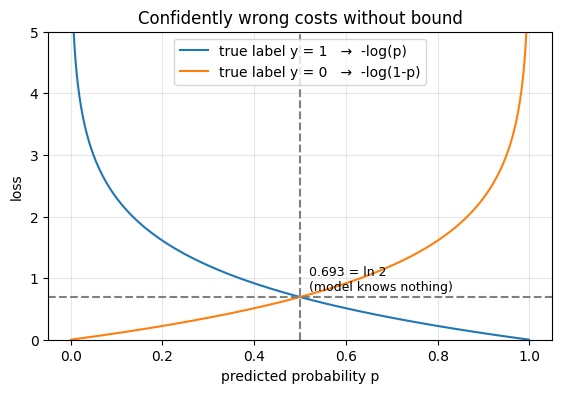

 true y   pred p     loss
      1     0.99   0.0101
      1     0.60   0.5108
      1     0.50   0.6931
      1     0.10   2.3026
      1     0.01   4.6052
      0     0.99   4.6052


In [5]:
p = torch.linspace(0.001, 0.999, 500)

plt.figure(figsize=(6.5, 4))
plt.plot(p, -torch.log(p),     label="true label y = 1   →  -log(p)")
plt.plot(p, -torch.log(1 - p), label="true label y = 0   →  -log(1-p)")
plt.axhline(0.693, ls="--", c="gray")
plt.axvline(0.5,   ls="--", c="gray")
plt.text(0.52, 0.8, "0.693 = ln 2\n(model knows nothing)", fontsize=9)
plt.xlabel("predicted probability p"); plt.ylabel("loss"); plt.ylim(0, 5)
plt.title("Confidently wrong costs without bound"); plt.legend(); plt.grid(alpha=.3); plt.show()

print(f"{'true y':>7} {'pred p':>8} {'loss':>8}")
for yv, pv in [(1,.99),(1,.60),(1,.50),(1,.10),(1,.01),(0,.99)]:
    L = -(yv*np.log(pv) + (1-yv)*np.log(1-pv))
    print(f"{yv:>7} {pv:>8.2f} {L:>8.4f}")

---
## 4. 🔴 Why logits, never probabilities

`BCEWithLogitsLoss` and `CrossEntropyLoss` fuse the squash with the log using the **log-sum-exp trick**:

$$\log\sum_j e^{z_j} = m + \log\sum_j e^{z_j - m},\qquad m=\max_j z_j$$

Subtracting the max keeps every exponential in a safe range.

In [6]:
big  = torch.tensor([[30.0]])
zero = torch.tensor([[0.0]])

p = torch.sigmoid(big)
print("sigmoid(30) in float32 :", p.item(), "  <-- 1.0 EXACTLY, precision is gone")
print("naive -log(1 - p)      :", (-torch.log(1 - p)).item(), "  <-- inf")
print("BCEWithLogitsLoss      :", nn.BCEWithLogitsLoss()(big, zero).item(), "  <-- exact")

print("\n--- and the DOUBLE-SQUASH bug (silent) ---")
logits  = torch.tensor([[-2.0], [0.0], [3.0]])
targets = torch.tensor([[ 0.0], [1.0], [1.0]])
print("correct (logits in)          :", round(nn.BCEWithLogitsLoss()(logits, targets).item(), 4))
print("WRONG   (sigmoid applied 2x) :", round(nn.BCEWithLogitsLoss()(logits.sigmoid(), targets).item(), 4))
print("No error raised. It just trains badly.")

sigmoid(30) in float32 : 1.0   <-- 1.0 EXACTLY, precision is gone
naive -log(1 - p)      : inf   <-- inf
BCEWithLogitsLoss      : 30.0   <-- exact

--- and the DOUBLE-SQUASH bug (silent) ---
correct (logits in)          : 0.2896
WRONG   (sigmoid applied 2x) : 0.5183
No error raised. It just trains badly.


### Multi-class: logits → softmax → `-log(p_true)`

In [7]:
z = torch.tensor([[2.0, 3.0, 1.0]])
true_class = torch.tensor([1])

p = z.softmax(dim=1)
print("logits :", z.tolist()[0])
print("softmax:", [round(v, 4) for v in p.tolist()[0]], " (sums to", round(p.sum().item(), 4), ")")
print("loss   = -log(p[1]) =", round(-np.log(p[0, 1].item()), 4))
print("PyTorch CrossEntropyLoss:", round(nn.CrossEntropyLoss()(z, true_class).item(), 4))

print("\nRaise the true-class logit 3.0 -> 5.0:")
z2 = torch.tensor([[2.0, 5.0, 1.0]])
print("softmax:", [round(v, 4) for v in z2.softmax(1).tolist()[0]])
print("loss   :", round(nn.CrossEntropyLoss()(z2, true_class).item(), 4))
print("\nOnly the true class enters the loss -- but softmax normalises, so raising it")
print("automatically pushes the others down. That coupling is what makes it work.")

logits : [2.0, 3.0, 1.0]
softmax: [0.2447, 0.6652, 0.09]  (sums to 1.0 )
loss   = -log(p[1]) = 0.4076
PyTorch CrossEntropyLoss: 0.4076

Raise the true-class logit 3.0 -> 5.0:
softmax: [0.0466, 0.9362, 0.0171]
loss   : 0.0659

Only the true class enters the loss -- but softmax normalises, so raising it
automatically pushes the others down. That coupling is what makes it work.


### The loss selection table

| Task | Output | Target | Loss |
|---|---|---|---|
| Regression | `(N,1)` values | float `(N,1)` | `MSELoss` / `HuberLoss` |
| Binary | `(N,1)` logits | float `(N,1)` | `BCEWithLogitsLoss` |
| **K-class, one label** | `(N,K)` logits | **long `(N,)`** | `CrossEntropyLoss` |
| Multi-label | `(N,K)` logits | float `(N,K)` | `BCEWithLogitsLoss` |
| Sequence labelling | `(N,T,K)` | long `(N,T)` | `CrossEntropyLoss` on `reshape(-1,K)` |

---
## 5. Optimizers — one family, two questions

```text
                  SGD:  θ -= lr·g
                        │
        ┌───────────────┴───────────────┐
   remember direction            scale per-parameter
        ▼                               ▼
  SGD + MOMENTUM                    RMSPROP
  v = βv + g                        s = βs + g²
  θ -= lr·v                         θ -= lr·g/√s
        │                               │
        └───────────────┬───────────────┘
                        ▼
                      ADAM  (both, + bias correction)
                        │
                        ▼
                     ADAMW  (decoupled weight decay) ← modern default
```

### Implement SGD-with-momentum by hand and check it against PyTorch

In [8]:
def manual_sgd_momentum(lr=0.1, momentum=0.9, steps=5):
    w, v = torch.tensor(5.0), 0.0
    out = []
    for _ in range(steps):
        g = 2 * w                      # loss = w^2  ->  dL/dw = 2w
        v = momentum * v + g
        w = w - lr * v
        out.append(w.item())
    return out

def torch_sgd_momentum(lr=0.1, momentum=0.9, steps=5):
    w = torch.tensor(5.0, requires_grad=True)
    opt = torch.optim.SGD([w], lr=lr, momentum=momentum)
    out = []
    for _ in range(steps):
        loss = w ** 2
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        out.append(w.item())
    return out

a, b = manual_sgd_momentum(), torch_sgd_momentum()
print(f"{'step':>5} {'manual':>10} {'pytorch':>10}")
for i, (x, y) in enumerate(zip(a, b), 1):
    print(f"{i:>5} {x:>10.5f} {y:>10.5f}")
print("\nIdentical. `v = momentum*v + g; w -= lr*v` IS torch.optim.SGD(momentum=...).")

 step     manual    pytorch
    1    4.00000    4.00000
    2    2.30000    2.30000
    3    0.31000    0.31000
    4   -1.54300   -1.54300
    5   -2.90210   -2.90210

Identical. `v = momentum*v + g; w -= lr*v` IS torch.optim.SGD(momentum=...).


### The optimizer race — same model, same data, same seed

SGD            final loss 0.25033
SGD+momentum   final loss 0.06765
RMSprop        final loss 0.05188
Adam           final loss 0.05816
AdamW          final loss 0.05820


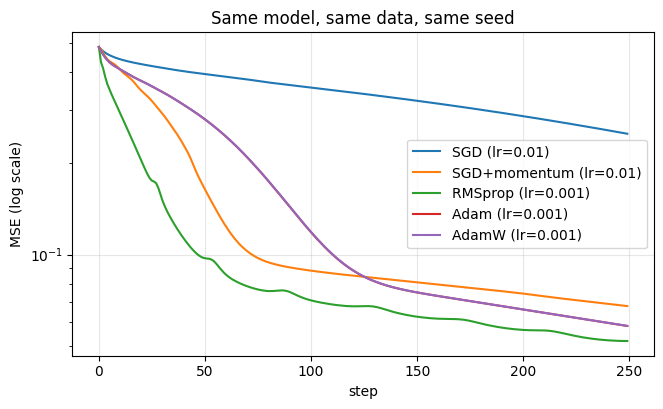

In [9]:
def make_model(in_dim=1, hidden=32, out_dim=1, seed=SEED):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(),
                         nn.Linear(hidden, hidden), nn.ReLU(),
                         nn.Linear(hidden, out_dim))

torch.manual_seed(SEED)
Xr = torch.linspace(-3, 3, 300).unsqueeze(1)
yr = torch.sin(Xr * 2) + 0.1 * torch.randn_like(Xr)

def race(opt_name, lr, epochs=250):
    m  = make_model()
    fn = nn.MSELoss()
    opt = {
        "SGD":          lambda: torch.optim.SGD(m.parameters(), lr=lr),
        "SGD+momentum": lambda: torch.optim.SGD(m.parameters(), lr=lr, momentum=0.9),
        "RMSprop":      lambda: torch.optim.RMSprop(m.parameters(), lr=lr),
        "Adam":         lambda: torch.optim.Adam(m.parameters(), lr=lr),
        "AdamW":        lambda: torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-2),
    }[opt_name]()
    hist = []
    for _ in range(epochs):
        loss = fn(m(Xr), yr)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        hist.append(loss.item())
    return hist

plt.figure(figsize=(7.5, 4.2))
for name, lr in [("SGD", 1e-2), ("SGD+momentum", 1e-2), ("RMSprop", 1e-3),
                 ("Adam", 1e-3), ("AdamW", 1e-3)]:
    h = race(name, lr)
    plt.plot(h, label=f"{name} (lr={lr})")
    print(f"{name:<14} final loss {h[-1]:.5f}")
plt.yscale("log"); plt.xlabel("step"); plt.ylabel("MSE (log scale)")
plt.title("Same model, same data, same seed"); plt.legend(); plt.grid(alpha=.3); plt.show()

---
## 6. Learning rate — the hyperparameter that matters most

```text
 too small       good           too large        way too large
   ●              ●               ● ●               ●
    ●              ╲             ╱ ╲ ╱ ╲            ╱ ╲
     ●              ●___        ●   ●   ●          NaN
  crawls          converges     oscillates       diverges
```

lr=0.1      final 0.06265
lr=0.03     final 0.00891
lr=0.01     final 0.01142
lr=0.001    final 0.05816
lr=0.0001   final 0.34498


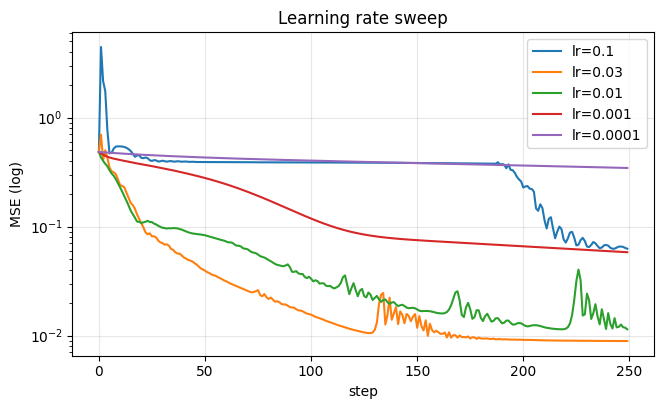

In [10]:
plt.figure(figsize=(7.5, 4.2))
for lr in [1e-1, 3e-2, 1e-2, 1e-3, 1e-4]:
    m, fn = make_model(), nn.MSELoss()
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    hist = []
    for _ in range(250):
        loss = fn(m(Xr), yr)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        hist.append(min(loss.item(), 10))          # clip for plotting
    plt.plot(hist, label=f"lr={lr}")
    print(f"lr={lr:<8} final {hist[-1]:.5f}")
plt.yscale("log"); plt.xlabel("step"); plt.ylabel("MSE (log)")
plt.title("Learning rate sweep"); plt.legend(); plt.grid(alpha=.3); plt.show()

### The LR range test — how professionals pick it

Increase the LR exponentially for a few hundred steps and plot loss against LR on a log axis. Pick where the curve is **steepest downward**, or one order of magnitude below where it explodes — *not* the minimum, because the minimum is already at the edge of instability.

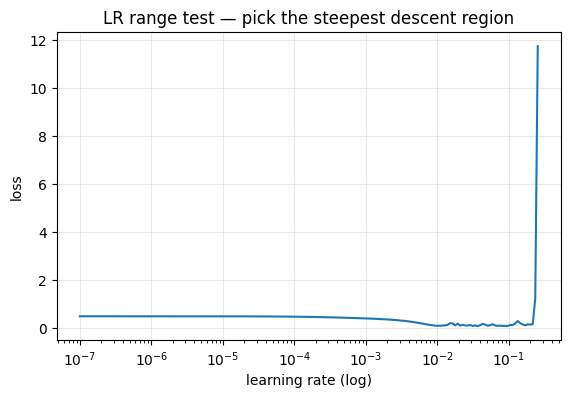

steepest descent near lr ~ 1.4e-01   -> a safe choice is ~1.4e-02


In [11]:
def lr_range_test(lo=1e-7, hi=1.0, steps=200):
    m, fn = make_model(), nn.MSELoss()
    opt = torch.optim.Adam(m.parameters(), lr=lo)
    mult = (hi / lo) ** (1 / steps)
    lrs, losses = [], []
    for _ in range(steps):
        loss = fn(m(Xr), yr)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        lrs.append(opt.param_groups[0]["lr"])
        losses.append(loss.item())
        opt.param_groups[0]["lr"] *= mult
        if loss.item() > 10 * losses[0]:
            break
    return lrs, losses

lrs, losses = lr_range_test()
plt.figure(figsize=(6.5, 4))
plt.plot(lrs, losses)
plt.xscale("log"); plt.xlabel("learning rate (log)"); plt.ylabel("loss")
plt.title("LR range test — pick the steepest descent region")
plt.grid(alpha=.3); plt.show()

best = lrs[int(np.argmin(np.gradient(losses)))]
print(f"steepest descent near lr ~ {best:.1e}   -> a safe choice is ~{best/10:.1e}")

---
## 7. Learning rate schedules

Large steps early to explore, small steps late to settle.

| Schedule | Use when |
|---|---|
| `StepLR` / `MultiStepLR` | classic vision recipes |
| `CosineAnnealingLR` | **modern default** |
| `ReduceLROnPlateau` | metric-driven, no epoch guessing |
| `OneCycleLR` | fast convergence in few epochs |
| linear warmup + cosine | **transformers, always** |

> **Ordering:** `optimizer.step()` **then** `scheduler.step()`. Most schedulers step per **epoch**; `OneCycleLR` and warmup step per **batch**. Getting this wrong silently ruins the run.

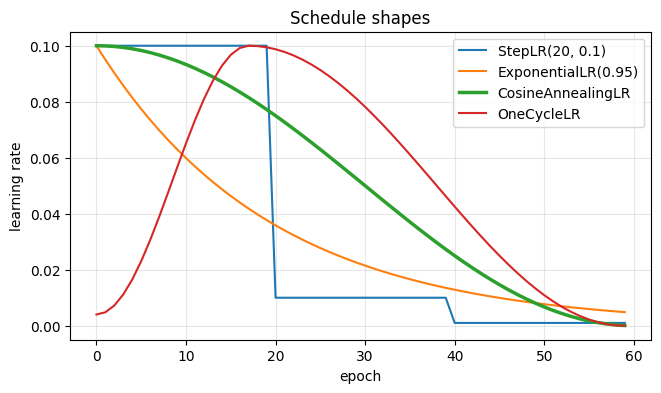

In [12]:
EP = 60
dummy = torch.nn.Parameter(torch.zeros(1))

def trace(make_sched, epochs=EP):
    opt = torch.optim.SGD([dummy], lr=0.1)
    sch = make_sched(opt)
    out = []
    for _ in range(epochs):
        out.append(opt.param_groups[0]["lr"])
        opt.step(); sch.step()
    return out

L = torch.optim.lr_scheduler
plt.figure(figsize=(7.5, 4))
plt.plot(trace(lambda o: L.StepLR(o, step_size=20, gamma=0.1)),      label="StepLR(20, 0.1)")
plt.plot(trace(lambda o: L.ExponentialLR(o, gamma=0.95)),            label="ExponentialLR(0.95)")
plt.plot(trace(lambda o: L.CosineAnnealingLR(o, T_max=EP)),          label="CosineAnnealingLR", lw=2.5)
plt.plot(trace(lambda o: L.OneCycleLR(o, max_lr=0.1, total_steps=EP)), label="OneCycleLR")
plt.xlabel("epoch"); plt.ylabel("learning rate"); plt.title("Schedule shapes")
plt.legend(); plt.grid(alpha=.3); plt.show()

---
## 8. Class imbalance

99% of tickets are normal. A model that always says "normal" scores 99% accuracy and is worthless.

| Lever | Trade-off |
|---|---|
| `pos_weight` / `weight=` | no data change, but **distorts probabilities** |
| Resampling | changes the effective distribution |
| **Threshold tuning** | free, keeps calibration — **try this first** |

In [13]:
torch.manual_seed(SEED)
N = 3000
Xi = torch.randn(N, 4)
score = Xi[:, 0] * 1.5 + Xi[:, 1] * 0.8 - 3.2                 # heavily negative bias
yi = torch.bernoulli(torch.sigmoid(score)).unsqueeze(1)
print("positive rate:", round(yi.mean().item(), 4))

n_pos = yi.sum(); n_neg = len(yi) - n_pos
pw = (n_neg / n_pos)
print("pos_weight =", round(pw.item(), 2))

def train_imbalanced(pos_weight=None, epochs=200):
    torch.manual_seed(SEED)
    m = nn.Sequential(nn.Linear(4, 16), nn.ReLU(), nn.Linear(16, 1))
    fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = torch.optim.AdamW(m.parameters(), lr=1e-2)
    for _ in range(epochs):
        loss = fn(m(Xi), yi)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    with torch.inference_mode():
        p = m(Xi).sigmoid()
    pred, truth = p >= 0.5, yi.bool()
    tp = (pred & truth).sum().item(); fp = (pred & ~truth).sum().item()
    fn_ = (~pred & truth).sum().item()
    return {"precision": tp/max(tp+fp,1), "recall": tp/max(tp+fn_,1),
            "predicted_positive": pred.sum().item()}, p

plain, p_plain = train_imbalanced(None)
wgt,   p_wgt   = train_imbalanced(torch.tensor([pw]))
print("\nplain      :", {k: round(v, 4) if isinstance(v, float) else v for k, v in plain.items()})
print("pos_weight :", {k: round(v, 4) if isinstance(v, float) else v for k, v in wgt.items()})

positive rate: 0.0937
pos_weight = 9.68

plain      : {'precision': 0.64, 'recall': 0.2278, 'predicted_positive': 100}
pos_weight : {'precision': 0.2782, 'recall': 0.79, 'predicted_positive': 798}


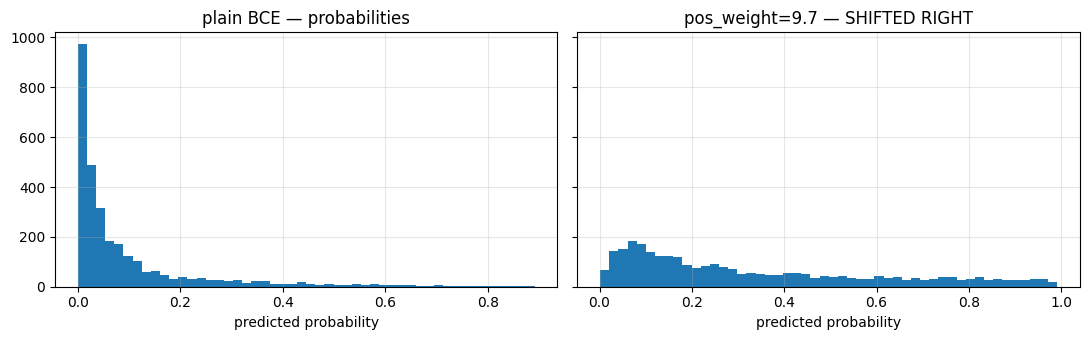

Recall went up, precision went down, and the probabilities are no longer calibrated.
That last part is the hidden cost of loss weighting.


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
ax[0].hist(p_plain.numpy(), bins=50); ax[0].set_title("plain BCE — probabilities")
ax[1].hist(p_wgt.numpy(),   bins=50); ax[1].set_title(f"pos_weight={pw:.1f} — SHIFTED RIGHT")
for a in ax: a.set_xlabel("predicted probability"); a.grid(alpha=.3)
plt.tight_layout(); plt.show()
print("Recall went up, precision went down, and the probabilities are no longer calibrated.")
print("That last part is the hidden cost of loss weighting.")

---
# 🌸 Part 2 — The complete pipeline on Iris

Everything above was a piece. Now the whole thing, done properly.

## 9. Load and split

**Two rules that people break constantly:**
1. **Stratify** the split — with 150 rows and 3 classes, a random split gives noisy metrics.
2. **Fit the scaler on TRAIN ONLY.** Fitting on everything leaks test information into training.

In [15]:
iris = load_iris()
X_all, y_all = iris.data.astype("float32"), iris.target.astype("int64")
print("X", X_all.shape, "| y", y_all.shape, "| classes:", iris.target_names.tolist())
print("features:", iris.feature_names)
print("class counts:", np.bincount(y_all))

# 60 / 20 / 20 stratified
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_all, y_all, test_size=0.4, random_state=SEED, stratify=y_all)
X_va, X_te, y_va, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp)

print("\ntrain", X_tr.shape, np.bincount(y_tr))
print("valid", X_va.shape, np.bincount(y_va))
print("test ", X_te.shape, np.bincount(y_te))

X (150, 4) | y (150,) | classes: ['setosa', 'versicolor', 'virginica']
features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
class counts: [50 50 50]

train (90, 4) [30 30 30]
valid (30, 4) [10 10 10]
test  (30, 4) [10 10 10]


In [16]:
scaler = StandardScaler().fit(X_tr)          # FIT ON TRAIN ONLY
X_tr_s = scaler.transform(X_tr).astype("float32")
X_va_s = scaler.transform(X_va).astype("float32")   # transform, never re-fit
X_te_s = scaler.transform(X_te).astype("float32")

print("train mean ~0, std ~1:", X_tr_s.mean(0).round(3), X_tr_s.std(0).round(3))
print("valid  (NOT exactly 0/1 -- correct!):", X_va_s.mean(0).round(3))

# Tensors. NOTE the target dtype: CrossEntropyLoss needs int64 CLASS INDICES.
Xtr = torch.from_numpy(X_tr_s); ytr = torch.from_numpy(y_tr)
Xva = torch.from_numpy(X_va_s); yva = torch.from_numpy(y_va)
Xte = torch.from_numpy(X_te_s); yte = torch.from_numpy(y_te)
print("\nfeatures", Xtr.dtype, tuple(Xtr.shape), "| targets", ytr.dtype, tuple(ytr.shape))

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=16, shuffle=True)
valid_loader = DataLoader(TensorDataset(Xva, yva), batch_size=32, shuffle=False)
test_loader  = DataLoader(TensorDataset(Xte, yte), batch_size=32, shuffle=False)

train mean ~0, std ~1: [-0. -0.  0. -0.] [1. 1. 1. 1.]
valid  (NOT exactly 0/1 -- correct!): [-0.009  0.048 -0.023  0.048]

features torch.float32 (90, 4) | targets torch.int64 (90,)


## 10. Model, loss, optimizer

In [17]:
class IrisNet(nn.Module):
    def __init__(self, in_dim=4, hidden=32, n_classes=3, p_drop=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(hidden, n_classes),          # (N, 3) RAW LOGITS -- no softmax
        )
    def forward(self, x):
        return self.net(x)

m = IrisNet()
print(m)
print("\ntrainable params:", sum(p.numel() for p in m.parameters()))
with torch.inference_mode():
    out = m(Xtr[:4])
print("output shape:", tuple(out.shape), "-> 3 logits per flower, NOT probabilities")
print("logits row 0:", out[0].tolist())

IrisNet(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=3, bias=True)
  )
)

trainable params: 1315
output shape: (4, 3) -> 3 logits per flower, NOT probabilities
logits row 0: [-0.02717381902039051, 0.04488227516412735, -0.06901140511035919]


### Parameter groups — do not decay biases or norm parameters

Biases have negligible capacity to overfit, and decaying them measurably hurts.

In [18]:
def make_optimizer(model, lr=1e-3, weight_decay=1e-2):
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (no_decay if p.ndim <= 1 or name.endswith(".bias") else decay).append(p)
    print(f"decayed tensors: {len(decay)} | not decayed (bias/norm): {len(no_decay)}")
    return torch.optim.AdamW([
        {"params": decay,    "weight_decay": weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ], lr=lr)

_ = make_optimizer(IrisNet())

decayed tensors: 3 | not decayed (bias/norm): 3


## 11. 🔑 Tiny-subset overfit test — BEFORE any tuning

| Outcome | Diagnosis |
|---|---|
| Cannot memorise 24 examples | **BUG** — stop, do not tune |
| Memorises them, valid is bad | pipeline correct → **generalisation** problem |

In [19]:
def tiny_overfit(n=24, epochs=400, lr=1e-2):
    torch.manual_seed(SEED)
    xs, ys = Xtr[:n], ytr[:n]
    mm  = IrisNet(p_drop=0.0)                     # dropout OFF -- we WANT memorisation
    opt = torch.optim.AdamW(mm.parameters(), lr=lr)
    fn  = nn.CrossEntropyLoss()
    for _ in range(epochs):
        mm.train()
        loss = fn(mm(xs), ys)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    mm.eval()
    with torch.inference_mode():
        acc = (mm(xs).argmax(1) == ys).float().mean().item()
    print(f"n={n}  final loss {loss.item():.6f}  train accuracy {acc:.3f}")
    return acc

acc = tiny_overfit()
print("PASS -- pipeline wired correctly" if acc > 0.95
      else "FAIL -- there is a BUG. Do not tune hyperparameters yet.")

n=24  final loss 0.000056  train accuracy 1.000
PASS -- pipeline wired correctly


## 12. The production training loop

Early stopping that **restores the best checkpoint**, cosine schedule, gradient clipping.

In [20]:
@torch.inference_mode()
def evaluate(model, loader, loss_fn, device="cpu"):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss_sum += loss_fn(logits, y).item() * x.size(0)
        correct  += (logits.argmax(1) == y).sum().item()
        total    += y.numel()
    return loss_sum / total, correct / total


def fit(model, train_loader, valid_loader, *, epochs=200, lr=1e-2,
        weight_decay=1e-2, patience=25, clip=1.0, device="cpu", verbose=True):

    model = model.to(device)
    loss_fn   = nn.CrossEntropyLoss(label_smoothing=0.0)
    optimizer = make_optimizer(model, lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_loss, best_state, bad = float("inf"), None, 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            loss = loss_fn(model(x), y)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)   # AFTER backward, BEFORE step
            optimizer.step()
            running += loss.item() * x.size(0)
        train_loss = running / len(train_loader.dataset)

        valid_loss, valid_acc = evaluate(model, valid_loader, loss_fn, device)
        scheduler.step()                                    # optimizer.step() THEN scheduler.step()

        history.append({"epoch": epoch, "train": train_loss, "valid": valid_loss,
                        "acc": valid_acc, "lr": optimizer.param_groups[0]["lr"]})

        if valid_loss < best_loss - 1e-4:
            best_loss, bad = valid_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
        else:
            bad += 1
            if bad >= patience:
                if verbose:
                    print(f"early stop at epoch {epoch}; best was epoch {best_epoch} "
                          f"(valid loss {best_loss:.4f})")
                break

        if verbose and (epoch % 25 == 0 or epoch == 1):
            print(f"epoch {epoch:>4} | train {train_loss:.4f} | valid {valid_loss:.4f} "
                  f"| acc {valid_acc:.3f} | lr {optimizer.param_groups[0]['lr']:.2e}")

    if best_state is not None:
        model.load_state_dict(best_state)       # RESTORE THE BEST, not the last
        if verbose:
            print("restored best checkpoint")
    return history

In [21]:
torch.manual_seed(SEED)
model = IrisNet()
history = fit(model, train_loader, valid_loader, epochs=200, lr=1e-2, patience=30)

decayed tensors: 3 | not decayed (bias/norm): 3
epoch    1 | train 0.9914 | valid 0.8149 | acc 0.733 | lr 1.00e-02
epoch   25 | train 0.0257 | valid 0.0356 | acc 1.000 | lr 9.62e-03
epoch   50 | train 0.0401 | valid 0.0652 | acc 0.967 | lr 8.54e-03
epoch   75 | train 0.0159 | valid 0.0767 | acc 0.967 | lr 6.91e-03
epoch  100 | train 0.0036 | valid 0.1037 | acc 0.967 | lr 5.00e-03
epoch  125 | train 0.0126 | valid 0.0920 | acc 0.967 | lr 3.09e-03
early stop at epoch 127; best was epoch 97 (valid loss 0.0228)
restored best checkpoint


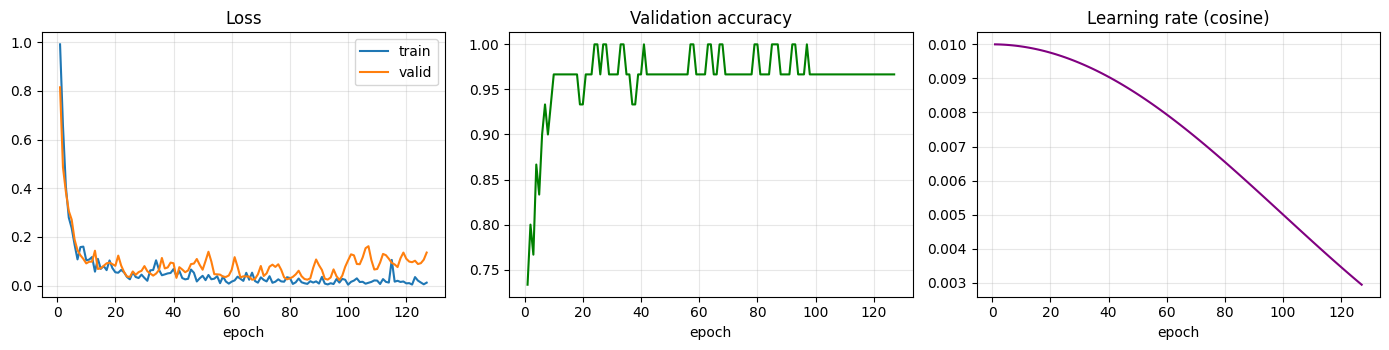

In [22]:
ep = [h["epoch"] for h in history]
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].plot(ep, [h["train"] for h in history], label="train")
ax[0].plot(ep, [h["valid"] for h in history], label="valid")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(ep, [h["acc"] for h in history], color="green")
ax[1].set_title("Validation accuracy"); ax[1].set_xlabel("epoch"); ax[1].grid(alpha=.3)
ax[2].plot(ep, [h["lr"] for h in history], color="purple")
ax[2].set_title("Learning rate (cosine)"); ax[2].set_xlabel("epoch"); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 13. Honest evaluation

Validation drove every decision. Now — and **only** now — we touch the test set. Once.

In [23]:
loss_fn = nn.CrossEntropyLoss()
va_loss, va_acc = evaluate(model, valid_loader, loss_fn)
print(f"VALIDATION  loss {va_loss:.4f}  accuracy {va_acc:.4f}   <- used for all decisions")

te_loss, te_acc = evaluate(model, test_loader, loss_fn)
print(f"TEST        loss {te_loss:.4f}  accuracy {te_acc:.4f}   <- touched ONCE, at the end")

VALIDATION  loss 0.0228  accuracy 1.0000   <- used for all decisions
TEST        loss 0.2832  accuracy 0.9333   <- touched ONCE, at the end


In [24]:
model.eval()
with torch.inference_mode():
    logits = model(Xte)
    probs  = logits.softmax(1)          # softmax ONLY here, for metrics
    preds  = logits.argmax(1)

cm = confusion_matrix(yte.numpy(), preds.numpy())
names = iris.target_names

print("Confusion matrix (rows = actual, cols = predicted)")
print(f"{'':<12}" + "".join(f"{n:>12}" for n in names))
for i, n in enumerate(names):
    print(f"{n:<12}" + "".join(f"{v:>12}" for v in cm[i]))

print("\n" + classification_report(yte.numpy(), preds.numpy(), target_names=names, digits=3))

Confusion matrix (rows = actual, cols = predicted)
                  setosa  versicolor   virginica
setosa                10           0           0
versicolor             0          10           0
virginica              0           2           8

              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      0.833     1.000     0.909        10
   virginica      1.000     0.800     0.889        10

    accuracy                          0.933        30
   macro avg      0.944     0.933     0.933        30
weighted avg      0.944     0.933     0.933        30



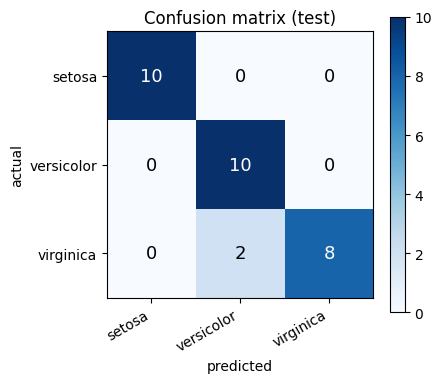

In [25]:
fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3), names, rotation=30, ha="right"); ax.set_yticks(range(3), names)
ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.set_title("Confusion matrix (test)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=13)
plt.colorbar(im); plt.tight_layout(); plt.show()

## 14. Confidence and calibration

The model gives a **score**. Turning that into a **decision** is a separate choice — and knowing *when the model is unsure* is often more valuable than raw accuracy.

In [26]:
conf, _ = probs.max(1)
correct = (preds == yte)

print(f"mean confidence when CORRECT : {conf[correct].mean():.4f}")
print(f"mean confidence when WRONG   : {conf[~correct].mean():.4f}" if (~correct).any() else "no errors")

print("\nLeast confident test predictions:")
order = conf.argsort()[:5]
print(f"{'actual':<12}{'predicted':<12}{'confidence':>11}")
for i in order:
    print(f"{names[yte[i]]:<12}{names[preds[i]]:<12}{conf[i]:>11.3f}")

# Abstain on low-confidence cases -> the "route to a human" pattern
for t in [0.0, 0.7, 0.9, 0.95]:
    keep = conf >= t
    if keep.sum() == 0:
        continue
    acc_kept = (preds[keep] == yte[keep]).float().mean().item()
    print(f"\nthreshold {t:.2f}: answer {keep.sum().item():>2}/{len(yte)} cases, "
          f"accuracy on answered = {acc_kept:.4f}")

mean confidence when CORRECT : 0.9843
mean confidence when WRONG   : 0.9496

Least confident test predictions:
actual      predicted    confidence
virginica   virginica         0.571
virginica   versicolor        0.903
virginica   versicolor        0.996
versicolor  versicolor        0.997
virginica   virginica         0.997

threshold 0.00: answer 30/30 cases, accuracy on answered = 0.9333

threshold 0.70: answer 29/30 cases, accuracy on answered = 0.9310

threshold 0.90: answer 29/30 cases, accuracy on answered = 0.9310

threshold 0.95: answer 28/30 cases, accuracy on answered = 0.9643


## 15. Save the model — with its preprocessing

In [27]:
import tempfile, os, json

path = os.path.join(tempfile.gettempdir(), "iris_model.pt")
torch.save({
    "model_state": model.state_dict(),
    "arch": {"in_dim": 4, "hidden": 32, "n_classes": 3},
    "scaler_mean": scaler.mean_.tolist(),        # ship the preprocessing!
    "scaler_scale": scaler.scale_.tolist(),
    "class_names": names.tolist(),
    "valid_acc": va_acc, "test_acc": te_acc,
    "seed": SEED,
}, path)

ckpt  = torch.load(path, map_location="cpu", weights_only=True)
fresh = IrisNet(**ckpt["arch"])
fresh.load_state_dict(ckpt["model_state"])
print("reload accuracy:", round(evaluate(fresh, test_loader, loss_fn)[1], 4), "| original:", round(te_acc, 4))
print("saved keys:", list(ckpt.keys()))

reload accuracy: 0.9333 | original: 0.9333
saved keys: ['model_state', 'arch', 'scaler_mean', 'scaler_scale', 'class_names', 'valid_acc', 'test_acc', 'seed']


---
## 16. Reading loss curves — the diagnosis drill

```text
(A) HEALTHY            (B) OVERFITTING       (C) UNDERFITTING
 │╲                     │╲                    │────────  both flat
 │ ╲___ train           │ ╲___ train          │────────  and high
 │  ╲__ valid           │ ╲__╱  valid ↑       │
 └────────> epoch       └────────> epoch      └────────> epoch
 keep training          regularise, stop      bigger model / bigger LR

(D) LR TOO HIGH        (E) NaN               (F) VALID < TRAIN
 │ ╱╲ ╱╲ ╱╲             │╲                    │╲___ valid
 │╱  ╲╱  ╲╱             │ ╲__ ✖ NaN           │ ╲___ train
 └────────> epoch       └────────> epoch      └────────> epoch
 divide LR by 3-10      clip, ÷10 LR,         NOT A BUG — dropout is
                        check for log(0)      on in train, off in eval
```

### Systematic order
1. Tiny-subset overfit test passes? No → **bug**. Stop.
2. Training loss falling? No → LR or capacity.
3. Validation tracking training? No → regularisation / more data.
4. Metric acceptable? No → wrong loss, wrong threshold, or wrong problem.

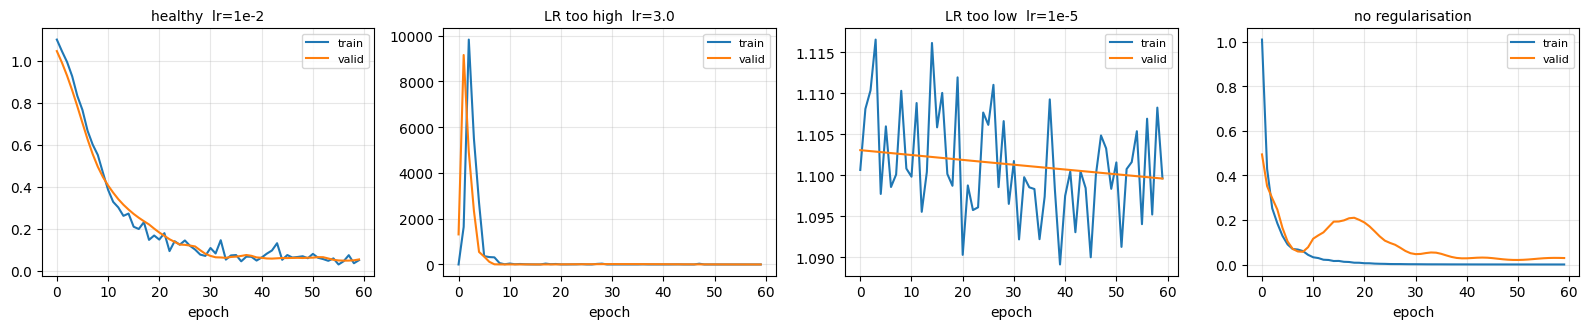

In [28]:
# Produce the pathological curves on purpose so you recognise them
def quick_run(lr, epochs=60, hidden=32, p_drop=0.2, wd=1e-2):
    torch.manual_seed(SEED)
    mm  = IrisNet(hidden=hidden, p_drop=p_drop)
    fn  = nn.CrossEntropyLoss()
    opt = torch.optim.AdamW(mm.parameters(), lr=lr, weight_decay=wd)
    tr_h, va_h = [], []
    for _ in range(epochs):
        mm.train()
        loss = fn(mm(Xtr), ytr)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        tr_h.append(loss.item())
        va_h.append(evaluate(mm, valid_loader, fn)[0])
    return tr_h, va_h

cases = [("healthy  lr=1e-2", dict(lr=1e-2)),
         ("LR too high  lr=3.0", dict(lr=3.0)),
         ("LR too low  lr=1e-5", dict(lr=1e-5)),
         ("no regularisation", dict(lr=1e-2, hidden=256, p_drop=0.0, wd=0.0))]

fig, ax = plt.subplots(1, 4, figsize=(16, 3.4))
for a, (title, kw) in zip(ax, cases):
    tr, va = quick_run(**kw)
    a.plot(tr, label="train"); a.plot(va, label="valid")
    a.set_title(title, fontsize=10); a.set_xlabel("epoch"); a.grid(alpha=.3); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 17. Exercises

In [29]:
# EXERCISE 1
# Implement MSELoss from scratch. Match nn.MSELoss() to 6 decimals.

# your code here

In [30]:
# EXERCISE 2
# Implement CrossEntropyLoss from scratch (logits -> log_softmax -> pick true class -> mean).
# Match nn.CrossEntropyLoss() to 6 decimals.

# your code here

In [31]:
# EXERCISE 3
# Implement Adam from scratch (m, v, bias correction) for loss = w**2 starting at w=5.
# Compare 10 steps against torch.optim.Adam.

# your code here

In [32]:
# EXERCISE 4
# Compare CosineAnnealingLR, StepLR, and NO scheduler over 150 epochs on Iris.
# Plot validation loss for all three. Which reaches the lowest value?

# your code here

In [33]:
# EXERCISE 5
# Sweep the decision threshold on the imbalanced ticket data from section 8
# (0.05 to 0.95) and plot precision, recall, F1.
# Then pick the operating point for: "missing a positive costs 5x a false alarm."

# your code here

In [34]:
# EXERCISE 6
# Break the Iris pipeline in ONE way (e.g. apply softmax before CrossEntropyLoss,
# or fit the scaler on the full dataset). Train, and describe what you observe.

# your code here

---
## 18. Recap

```text
LOSS       differentiable, gives gradients. Accuracy cannot be a loss.
           regression: MSE(mean) / MAE(median) / Huber(both)
           classification: CE on LOGITS. 0.693 = learned nothing.
OPTIMIZER  SGD → +momentum(direction) → +RMSProp(per-param scale) = Adam → AdamW
           AdamW decouples weight decay. Modern default.
LR         matters more than anything. LR range test. Cosine schedule. Warmup for transformers.
IMBALANCE  threshold tuning first; pos_weight distorts calibration.
LOOP       clip after backward, before step. Restore the BEST checkpoint.
HONESTY    fit scalers on train only. Touch test EXACTLY ONCE.
```

**Next class:** convolutional neural networks. The loop stays exactly the same. Only the model changes — which has been the point for two days.

### References

- [`torch.nn` losses](https://docs.pytorch.org/docs/stable/nn.html#loss-functions) · [`torch.optim`](https://docs.pytorch.org/docs/stable/optim.html)
- [LR schedulers](https://docs.pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate)
- [Adam](https://arxiv.org/abs/1412.6980) · [AdamW](https://arxiv.org/abs/1711.05101) · [LR range test](https://arxiv.org/abs/1506.01186)